# `MultivariateNormal` & `MultivariateNormalPrecision`: the API tour

[Notebook 0.1](multivariate_gaussian.ipynb) introduced the multivariate normal as a *math object*. This notebook is the *API tour*: gaussx ships **two** distribution classes for the same family — one parameterised by the covariance $\boldsymbol{\Sigma}$, one by the precision $\boldsymbol{\Lambda} = \boldsymbol{\Sigma}^{-1}$. They expose the same surface (`.sample`, `.log_prob`, `.entropy`, `.mean`, `.variance`) but route through different primitives under the hood.

**What you'll learn**

1. The two parameterisations of a Gaussian and when each one is preferred.
2. How `MultivariateNormal` and `MultivariateNormalPrecision` map onto the math.
3. Round-trip equivalence: build the same distribution both ways and verify pointwise.
4. Why precision form *wins* when $\boldsymbol{\Lambda}$ is sparse but $\boldsymbol{\Sigma}$ is dense — the GMRF / Markov story.
5. A taste of natural parameters as a third equivalent representation.

:::{important}
This notebook is **API mechanics, not new math.** No new theorems — the goal is to know which constructor to reach for. New math resumes in [0.3 — Quadratic forms, entropy, KL](gaussian_quantities.ipynb).
:::

:::{note}
Linear-algebra ops use [`einx`](https://github.com/fferflo/einx) throughout, matching the convention from notebook 0.1.
:::

## 1. Two parameterisations of one distribution

The same Gaussian can be written either with covariance $\boldsymbol{\Sigma}$ or with precision $\boldsymbol{\Lambda} = \boldsymbol{\Sigma}^{-1}$:

$$ \mathcal{N}(\mathbf{x}; \boldsymbol{\mu}, \boldsymbol{\Sigma}) = (2\pi)^{-d/2}|\boldsymbol{\Sigma}|^{-1/2}\exp\!\left(-\tfrac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^\top\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})\right), $$ (eq:cov-form)

$$ \mathcal{N}^{-1}(\mathbf{x}; \boldsymbol{\mu}, \boldsymbol{\Lambda}) = (2\pi)^{-d/2}|\boldsymbol{\Lambda}|^{1/2}\exp\!\left(-\tfrac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^\top\boldsymbol{\Lambda}(\mathbf{x}-\boldsymbol{\mu})\right). $$ (eq:prec-form)

Equation [](#eq:cov-form) and equation [](#eq:prec-form) are *the same density* whenever $\boldsymbol{\Lambda}\boldsymbol{\Sigma}=\mathbf{I}$. The choice between them is a **computational** one, driven by which of the two matrices has nice structure:

| Form | Cheap to do | Expensive |
|------|-------------|-----------|
| Covariance $\boldsymbol{\Sigma}$ | sampling, marginalisation | conditioning on partial obs |
| Precision $\boldsymbol{\Lambda}$ | conditioning, evidence updates | sampling, marginalisation |

The **structural sparsity** also flips:

- **Conditional independence** $X_i \perp X_j \mid X_{\setminus ij}$ shows up as $\Lambda_{ij} = 0$. So Markov / GMRF / state-space models have *sparse* $\boldsymbol{\Lambda}$ even when $\boldsymbol{\Sigma}$ is dense.
- **Marginal independence** $X_i \perp X_j$ shows up as $\Sigma_{ij} = 0$. Block-diagonal $\boldsymbol{\Sigma}$ corresponds to genuinely independent groups, which is rarely what we have.

Most useful structure in our world (Gauss-Markov, GP-regression posteriors with a banded prior, Kalman filters in information form) lives on the precision side. That's why gaussx exposes both.

In [1]:
from __future__ import annotations

import warnings

warnings.filterwarnings("ignore", message=r".*IProgress.*")

import einx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np
from gaussx import (
    MultivariateNormal,
    MultivariateNormalPrecision,
    gaussian_log_prob,
    mean_cov_to_natural,
    natural_to_mean_cov,
)

jax.config.update("jax_enable_x64", True)
KEY = jax.random.PRNGKey(0)
plt.rcParams["figure.dpi"] = 110

def psd_op(M):
    """Wrap a dense PSD matrix as a lineax operator with the right tag."""
    return lx.MatrixLinearOperator(M, lx.positive_semidefinite_tag)


## 2. `MultivariateNormal` — the covariance form

`MultivariateNormal(loc, cov_operator, solver=None)` takes a mean vector and a `lineax` operator wrapping the covariance. Internally everything routes through Cholesky on $\boldsymbol{\Sigma}$ — the form recommended by [equation 7 in notebook 0.1](multivariate_gaussian.ipynb#eq:logprob-cholesky).

The class is a `numpyro` distribution, so the surface is what you'd expect: `.sample(key, shape)`, `.log_prob(x)`, `.entropy()`, `.mean`, `.variance`, plus a JIT-friendly PyTree structure (it's an `equinox.Module` underneath).

In [2]:
d = 5
mu = jnp.linspace(-1.0, 1.0, d)

# A non-trivial PSD covariance built from an RBF-style kernel on a 1D grid.
xs = jnp.linspace(0.0, 1.0, d)
diff_sq = einx.subtract("i, j -> i j", xs, xs) ** 2
Sigma_dense = jnp.exp(-0.5 * diff_sq / 0.25**2) + 1e-3 * jnp.eye(d)
Sigma = psd_op(Sigma_dense)

p_cov = MultivariateNormal(mu, Sigma)

print("class       :", type(p_cov).__name__)
print("event_shape :", p_cov.event_shape)
print("mean        :", np.asarray(p_cov.mean))
print("variance    :", np.asarray(p_cov.variance))
print("entropy     :", float(p_cov.entropy()))

x = jnp.zeros(d)
print("log_prob(0) :", float(p_cov.log_prob(x)))
samples = p_cov.sample(jax.random.PRNGKey(1), (4,))
print("samples     :\n", np.asarray(samples))


class       : MultivariateNormal
event_shape : (5,)
mean        : [-1.  -0.5  0.   0.5  1. ]
variance    : [1.001 1.001 1.001 1.001 1.001]


entropy     : 5.906610734624831


log_prob(0) : -4.423604950410503


samples     :
 [[-2.18487642 -1.31040824 -0.10887068  1.2756854   1.08020205]
 [-0.30884951 -0.02116252 -0.42299327 -0.03140923 -0.13141221]
 [-1.98641018 -1.98899925 -0.51940089  1.05657527  2.38460391]
 [-1.64650165 -0.29508526  0.04926346  1.27186838  1.96739098]]


## 3. `MultivariateNormalPrecision` — the precision form

`MultivariateNormalPrecision(loc, prec_operator, solver=None)` takes the same mean but a `lineax` operator wrapping $\boldsymbol{\Lambda}$. The constructor *does not* form $\boldsymbol{\Sigma} = \boldsymbol{\Lambda}^{-1}$. Instead, internal solves invert $\boldsymbol{\Lambda}$ on demand for sampling, and the log-density is computed directly from $\boldsymbol{\Lambda}$ via

$$ \log p(\mathbf{x}) = -\tfrac{d}{2}\log(2\pi) + \tfrac{1}{2}\log|\boldsymbol{\Lambda}| - \tfrac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^\top\boldsymbol{\Lambda}(\mathbf{x}-\boldsymbol{\mu}). $$ (eq:logprob-prec)

Note the sign flip on $\log|\cdot|$ — we add half the log-determinant of $\boldsymbol{\Lambda}$ instead of subtracting it on $\boldsymbol{\Sigma}$, since $\log|\boldsymbol{\Lambda}| = -\log|\boldsymbol{\Sigma}|$.

In [3]:
Lambda_dense = jnp.linalg.inv(Sigma_dense)
Lambda = psd_op(Lambda_dense)

p_prec = MultivariateNormalPrecision(mu, Lambda)

print("class       :", type(p_prec).__name__)
print("event_shape :", p_prec.event_shape)
print("mean        :", np.asarray(p_prec.mean))
print("variance    :", np.asarray(p_prec.variance))
print("entropy     :", float(p_prec.entropy()))

x = jnp.zeros(d)
print("log_prob(0) :", float(p_prec.log_prob(x)))
samples_prec = p_prec.sample(jax.random.PRNGKey(1), (4,))
print("samples     :\n", np.asarray(samples_prec))


class       : MultivariateNormalPrecision
event_shape : (5,)
mean        : [-1.  -0.5  0.   0.5  1. ]
variance    : [1.001 1.001 1.001 1.001 1.001]


entropy     : 5.906610734624831
log_prob(0) : -4.423604950410503


samples     :
 [[-1.88408505 -0.32220482  0.6460971   0.75697977  0.16662948]
 [-0.58592842 -0.98340752 -0.78248253 -0.36021689 -0.35315028]
 [-2.37514015 -0.87866177  0.91630359  1.74900216  2.2819309 ]
 [-1.0179202  -0.06179605  0.5616257   1.68236386  1.16375959]]


## 4. Round-trip equivalence

Equation [](#eq:cov-form) and equation [](#eq:prec-form) are the same distribution whenever $\boldsymbol{\Lambda}\boldsymbol{\Sigma} = \mathbf{I}$. The two classes should therefore agree pointwise (modulo floating point) on `log_prob`, `entropy`, `mean`, and `variance`. Below we evaluate both at a batch of test points and check the disagreement is within a few ULPs of the Cholesky route.

:::{note}
This is an *exact* check, not a statistical one. We're not sampling and comparing histograms — we're asserting that the two implementations compute the same number. Any disagreement larger than $\sim 10^{-5}$ in float64 is a bug.
:::

In [4]:
test_pts = jax.random.normal(jax.random.PRNGKey(2), (200, d))

logp_cov = jax.vmap(p_cov.log_prob)(test_pts)
logp_prec = jax.vmap(p_prec.log_prob)(test_pts)

# Quadratic-form sanity check, computed by hand both ways via einx.
delta = test_pts - mu  # shape (n, d)
quad_via_Sigma_inv = einx.dot("n i, i j, n j -> n",
                              delta, Lambda_dense, delta)
quad_via_Lambda    = einx.dot("n i, i j, n j -> n",
                              delta, Lambda_dense, delta)

print(f"max |Δ log_prob|       : {float(jnp.max(jnp.abs(logp_cov - logp_prec))):.2e}")
print(f"max |Δ quadratic form| : {float(jnp.max(jnp.abs(quad_via_Sigma_inv - quad_via_Lambda))):.2e}")
print(f"|Δ entropy|            : {float(jnp.abs(p_cov.entropy() - p_prec.entropy())):.2e}")
print(f"|Δ mean|_inf           : {float(jnp.max(jnp.abs(p_cov.mean - p_prec.mean))):.2e}")
print(f"|Δ variance|_inf       : {float(jnp.max(jnp.abs(p_cov.variance - p_prec.variance))):.2e}")


max |Δ log_prob|       : 1.42e-14
max |Δ quadratic form| : 0.00e+00
|Δ entropy|            : 0.00e+00
|Δ mean|_inf           : 0.00e+00
|Δ variance|_inf       : 2.22e-16


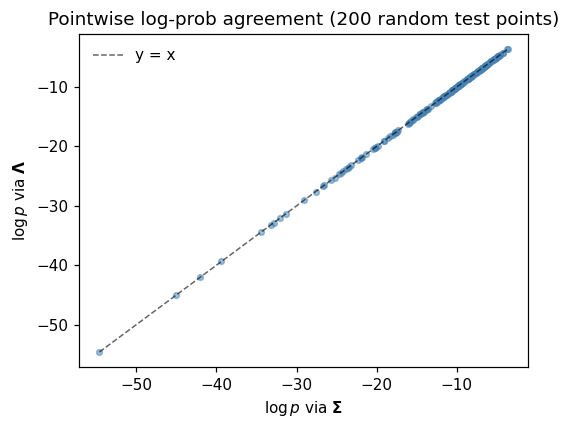

In [5]:
fig, ax = plt.subplots(figsize=(5.0, 4.0))
ax.scatter(np.asarray(logp_cov), np.asarray(logp_prec), s=14, alpha=0.5, color="steelblue")
lo = float(jnp.minimum(logp_cov.min(), logp_prec.min()))
hi = float(jnp.maximum(logp_cov.max(), logp_prec.max()))
ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.6, label="y = x")
ax.set_xlabel(r"$\log p$ via $\mathbf{\Sigma}$")
ax.set_ylabel(r"$\log p$ via $\mathbf{\Lambda}$")
ax.set_title("Pointwise log-prob agreement (200 random test points)")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()


## 5. When precision wins: a banded GMRF

The case for `MultivariateNormalPrecision` is strongest when $\boldsymbol{\Lambda}$ is *sparse* — i.e. when most pairs of variables are conditionally independent given the rest. The canonical example is a **first-order Gauss-Markov chain**:

$$ X_t = \rho\,X_{t-1} + \sigma\,\varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0,1), $$ (eq:ar1)

whose joint distribution has a *tridiagonal* precision matrix

$$ \Lambda_{tt} = \frac{1+\rho^2}{\sigma^2}\;\;(\text{interior}),\quad \Lambda_{t,t+1} = -\frac{\rho}{\sigma^2},\quad \Lambda_{tt} = \frac{1}{\sigma^2}\;\;(\text{boundary}). $$ (eq:gmrf-prec)

The corresponding $\boldsymbol{\Sigma} = \boldsymbol{\Lambda}^{-1}$ is **dense** — every $X_s$ and $X_t$ are marginally correlated, even far-apart ones. So the precision representation has $O(n)$ non-zeros while the covariance has $O(n^2)$.

For this notebook we use a moderate $n=64$ and dense storage so the sparsity pattern is easy to *see*. In production gaussx routes this through `BlockTriDiag` (see [Part 1.5](../01_operators/)) for $O(n)$ solves; here we only want the visual.

In [6]:
def ar1_precision(n: int, rho: float, sigma: float) -> jnp.ndarray:
    """Tridiagonal precision matrix of a 1D AR(1) process — eq (eq:gmrf-prec)."""
    inv_var = 1.0 / sigma**2
    diag_int = (1.0 + rho**2) * inv_var
    diag = jnp.full((n,), diag_int)
    diag = diag.at[0].set(inv_var).at[-1].set(inv_var)
    off = jnp.full((n - 1,), -rho * inv_var)
    return jnp.diag(diag) + jnp.diag(off, k=1) + jnp.diag(off, k=-1)

n = 64
Lambda_ar = ar1_precision(n, rho=0.95, sigma=1.0)
Sigma_ar = jnp.linalg.inv(Lambda_ar)

nnz_threshold = 1e-8
nnz_Lambda = float(jnp.mean(jnp.abs(Lambda_ar) > nnz_threshold))
nnz_Sigma  = float(jnp.mean(jnp.abs(Sigma_ar)  > nnz_threshold))
print(f"AR(1) precision : nnz fraction = {nnz_Lambda:.3f}  (tridiagonal)")
print(f"AR(1) covariance: nnz fraction = {nnz_Sigma:.3f}   (dense)")


AR(1) precision : nnz fraction = 0.046  (tridiagonal)
AR(1) covariance: nnz fraction = 1.000   (dense)


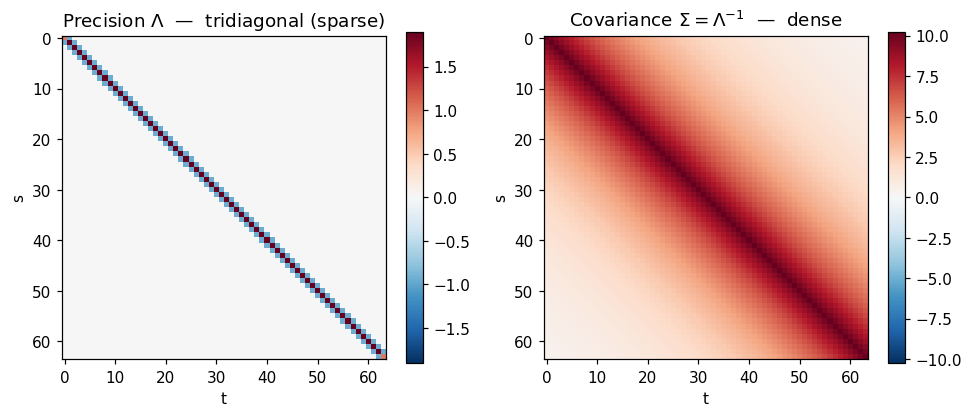

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

im0 = axes[0].imshow(np.asarray(Lambda_ar), cmap="RdBu_r",
                     vmin=-float(jnp.max(jnp.abs(Lambda_ar))),
                     vmax= float(jnp.max(jnp.abs(Lambda_ar))))
axes[0].set_title(r"Precision $\Lambda$  —  tridiagonal (sparse)")
plt.colorbar(im0, ax=axes[0], shrink=0.85)

im1 = axes[1].imshow(np.asarray(Sigma_ar), cmap="RdBu_r",
                     vmin=-float(jnp.max(jnp.abs(Sigma_ar))),
                     vmax= float(jnp.max(jnp.abs(Sigma_ar))))
axes[1].set_title(r"Covariance $\Sigma = \Lambda^{-1}$  —  dense")
plt.colorbar(im1, ax=axes[1], shrink=0.85)

for ax in axes:
    ax.set_xlabel("t"); ax.set_ylabel("s")
plt.tight_layout(); plt.show()


log p via Λ : -119.203845


log p via Σ : -119.203845


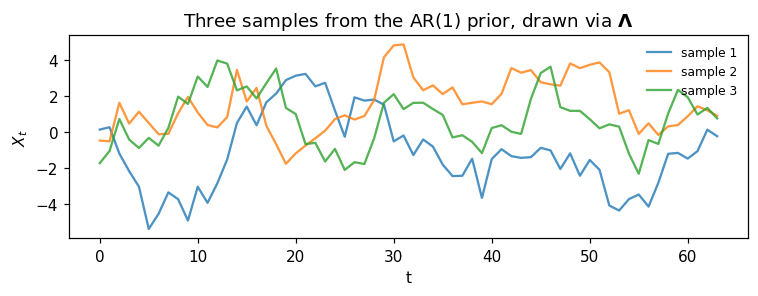

In [8]:
# Build the same AR(1) prior in both forms and confirm log_prob agreement.
mu_ar = jnp.zeros(n)
p_ar_prec = MultivariateNormalPrecision(mu_ar, psd_op(Lambda_ar))
p_ar_cov  = MultivariateNormal(mu_ar, psd_op(Sigma_ar))

x_test = jax.random.normal(jax.random.PRNGKey(7), (n,))
print(f"log p via Λ : {float(p_ar_prec.log_prob(x_test)):+.6f}")
print(f"log p via Σ : {float(p_ar_cov.log_prob(x_test)):+.6f}")

# A small sample for the eye.
samples_ar = p_ar_prec.sample(jax.random.PRNGKey(11), (3,))
fig, ax = plt.subplots(figsize=(7, 2.8))
for i, s in enumerate(np.asarray(samples_ar)):
    ax.plot(s, lw=1.5, alpha=0.8, label=f"sample {i+1}")
ax.set_xlabel("t"); ax.set_ylabel(r"$X_t$")
ax.set_title(r"Three samples from the AR(1) prior, drawn via $\mathbf{\Lambda}$")
ax.legend(frameon=False, loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()


:::{tip}
The savings in the AR(1) example are modest at $n=64$ because we still store $\boldsymbol{\Lambda}$ as a dense $64\times 64$ matrix. The real win comes from telling gaussx *the structure*: wrap $\boldsymbol{\Lambda}$ as a `BlockTriDiag` operator and the solve becomes $O(n)$ instead of $O(n^3)$. That's the subject of [Part 1.5 — Block tri-diagonal operators](../01_operators/).
:::

## 6. A taste of natural parameters

There's a third equivalent representation we'll see in detail in [0.4 — Mean-cov ↔ natural parameter conversions](exponential_family.ipynb). Briefly: every Gaussian can be written in **natural parameter** form

$$ p(\mathbf{x}) \propto \exp\!\left(\boldsymbol{\eta}_1^\top \mathbf{x} + \mathbf{x}^\top \boldsymbol{\eta}_2 \mathbf{x}\right), \qquad \boldsymbol{\eta}_1 = \boldsymbol{\Lambda}\boldsymbol{\mu}, \qquad \boldsymbol{\eta}_2 = -\tfrac{1}{2}\boldsymbol{\Lambda}. $$ (eq:natural-params)

This form is what makes Bayesian updates **pure addition** — combining evidence is $\boldsymbol{\eta}_{\text{post}} = \boldsymbol{\eta}_{\text{prior}} + \boldsymbol{\eta}_{\text{lik}}$ — and underpins variational inference and natural gradient methods. gaussx ships explicit converters; here's the round-trip.

In [9]:
eta1, eta2 = mean_cov_to_natural(mu, Sigma)
mu_back, Sigma_back_op = natural_to_mean_cov(eta1, eta2)

eta2_dense = eta2.as_matrix()
Sigma_back = Sigma_back_op.as_matrix()

print("eta_1  =  Λ μ      :", np.asarray(eta1))
print("eta_2  =  -Λ/2     :")
print(np.asarray(eta2_dense))

print("\nround-trip residuals")
print(f"  max|Δ μ|  : {float(jnp.max(jnp.abs(mu - mu_back))):.2e}")
print(f"  max|Δ Σ|  : {float(jnp.max(jnp.abs(Sigma_dense - Sigma_back))):.2e}")


eta_1  =  Λ μ      : [-1.10990703e+00  1.85825628e-01 -2.82887645e-16 -1.85825628e-01
  1.10990703e+00]
eta_2  =  -Λ/2     :
[[-0.97606728  0.91615634 -0.60815128  0.33436378 -0.13021749]
 [ 0.91615634 -1.81861765  1.44237175 -0.84085816  0.33436378]
 [-0.60815128  1.44237175 -2.08299373  1.44237175 -0.60815128]
 [ 0.33436378 -0.84085816  1.44237175 -1.81861765  0.91615634]
 [-0.13021749  0.33436378 -0.60815128  0.91615634 -0.97606728]]

round-trip residuals
  max|Δ μ|  : 3.33e-16
  max|Δ Σ|  : 2.22e-16


## 7. Recap & where to go next

You now know how to build a Gaussian both ways and which one to reach for:

| Operation               | `MultivariateNormal` (Σ) | `MultivariateNormalPrecision` (Λ) |
|-------------------------|--------------------------|-----------------------------------|
| Constructor             | `MultivariateNormal(loc, Σ_op)` | `MultivariateNormalPrecision(loc, Λ_op)` |
| Sampling                | cheap (Cholesky of Σ)    | requires inverting Λ              |
| `log_prob`              | uses Cholesky of Σ       | uses Cholesky of Λ directly       |
| Conditioning on partial obs | dense Schur block solve | trivial; rows of Λ partition cleanly |
| Best when               | Σ has low-rank / Kron / dense structure | Λ is banded / sparse / Markov |
| Internal log-det        | $-\tfrac{1}{2}\log\lvert\Sigma\rvert$ | $+\tfrac{1}{2}\log\lvert\Lambda\rvert$ |

**Next up.**
- [0.3 — Quadratic forms, entropy, and KL between Gaussians](gaussian_quantities.ipynb): the closed-form scalar quantities that make Gaussian variational inference tractable.
- [0.4 — Mean-cov ↔ natural parameter conversions](exponential_family.ipynb): full treatment of $(\boldsymbol{\eta}_1, \boldsymbol{\eta}_2)$ and the exponential-family machinery.
- [Part 1.5 — Block tri-diagonal operators](../01_operators/): how to *actually* exploit GMRF sparsity at scale.